### Project 4 - Accuracy and Beyond
**Author:** Nana Y. Frimpong

Accuracy isn't the whole story with recommender systems. Konstan and Riedl (2012) point out that a lot of research shifted from "which algorithm is best" to "what's the actual user experience," since the same algorithm can feel completely different depending on how it's presented. Gunawardana and Shani (2009) back this up from the metrics side. They show that an algorithm which wins on RMSE for predicting ratings can lose on precision and recall for recommending items, on the exact same data. Different tasks like predicting ratings, recommending good items, and optimizing utility call for different metrics. Picking the wrong one can lead to choosing the wrong algorithm entirely. So even before diversity or novelty come up, picking the "right" accuracy metric already depends on what the system is actually trying to do.

This is where beyond-accuracy measures like diversity and novelty matter. Gunawardana and Shani touch on this too, pointing to work that looked at diversifying whole recommendation lists rather than judging items one by one, and using inverse popularity to capture how much new information an item carries. In practice, platforms like YouTube and Netflix build this in on purpose. They nudge recommendations away from just the highest-scored items so people don't get stuck seeing the same narrow slice of content over and over. It's a real trade-off though, not free. Pushing for more diversity usually costs some accuracy.

This project follows the same logic on a Last.fm listening dataset. We compare two recommender algorithms on accuracy, then re-rank for diversity and novelty and see what's gained and what's given up.

### Assignment Goal
1. Compare accuracy of two recommender algorithms
2. Implement a beyond-accuracy goal (diversity/novelty via MMR re-ranking)
3. Compare accuracy before vs. after the change
4. Discuss online evaluation design

### Dataset

We use the Last.fm Listening History Dataset (personal scrobble export):

Last.fm Listening History Data. Kaggle.
https://www.kaggle.com/datasets/harshal19t/lastfm-music-artists-dataset

> Description of Dataset

The data contains 166,153 scrobbles, which are individual song plays. These were logged across 11 users over January 2021. Each row includes the Username, Artist, Track, Album, and a timestamp of when the play happened.

This is implicit feedback, not explicit ratings. There are no 1 to 5 star scores. A play simply means the user listened to that track, which we treat as a positive signal of interest. There is no signal for dislike, since users don't scrobble songs they skip or avoid.

The dataset has an unusual shape for a recommender task. There are only 11 unique users, but about 22,800 unique artists and 67,000 unique tracks. That is the opposite of most recommendation datasets, which usually have many users and a moderate sized catalog. This is exactly why user based collaborative filtering and item based collaborative filtering perform very differently here, which we cover in the algorithms section.

### References

Gunawardana, A., & Shani, G. (2009). A survey of accuracy evaluation metrics of recommendation tasks. *Journal of Machine Learning Research, 10*, 2935–2962.

Hu, Y., Koren, Y., & Volinsky, C. (2008). Collaborative filtering for implicit feedback datasets. In *2008 Eighth IEEE International Conference on Data Mining* (pp. 263–272). IEEE. https://doi.org/10.1109/ICDM.2008.22

Konstan, J. A., & Riedl, J. (2012). Recommender systems: From algorithms to user experience. *User Modeling and User-Adapted Interaction, 22*(1–2), 101–123. https://doi.org/10.1007/s11257-011-9112-x

*Last.fm Listening History Data.* [Data set]. Kaggle. https://www.kaggle.com/datasets/harshal19t/lastfm-music-artists-dataset



### Data Preprocessing


In [33]:

## Importing Libraries
import pandas as pd
import numpy as np
from scipy.sparse import csr_matrix
from sklearn.metrics.pairwise import cosine_similarity
import implicit
import matplotlib.pyplot as plt

# Random seed for reproducibility
np.random.seed(42)
pd.set_option('display.max_columns', None)
import matplotlib.pyplot as plt

# Load Dataset
df = pd.read_csv('/Users/nanafrimpong/Desktop/SPS Summer 2026/Data 612/Unit 2/Project 3/Last.fm_data.csv', index_col=0)
df.columns = ['user', 'artist', 'track', 'album', 'date', 'time']
print(f"Rows (scrobbles): {len(df):,}")
print(f"Unique users: {df['user'].nunique()}")
print(f"Unique artists: {df['artist'].nunique()}")
print(f"Unique tracks: {df['track'].nunique()}")
df.head()


Rows (scrobbles): 166,153
Unique users: 11
Unique artists: 22823
Unique tracks: 67241


,user,artist,track,album,date,time
0,Babs_05,Isobel Campbell,The Circus Is Leaving Town,Ballad of the Broken Seas,31 Jan 2021,23:36
1,Babs_05,Isobel Campbell,Dusty Wreath,Ballad of the Broken Seas,31 Jan 2021,23:32
2,Babs_05,Isobel Campbell,Honey Child What Can I Do?,Ballad of the Broken Seas,31 Jan 2021,23:28
3,Babs_05,Isobel Campbell,It's Hard To Kill A Bad Thing,Ballad of the Broken Seas,31 Jan 2021,23:25
4,Babs_05,Isobel Campbell,Saturday's Gone,Ballad of the Broken Seas,31 Jan 2021,23:21


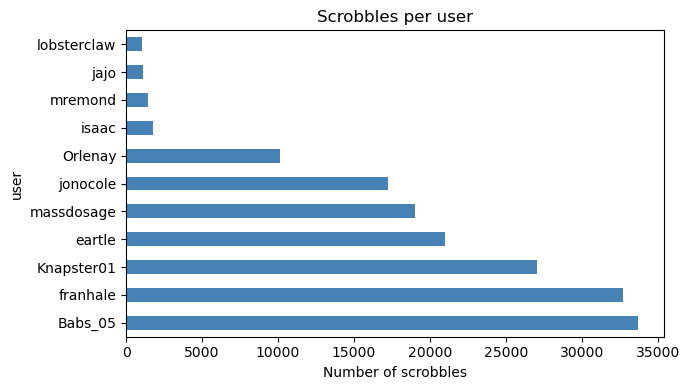

In [34]:
df['user'].value_counts().plot(kind='barh', figsize=(7,4), color='steelblue')
plt.title('Scrobbles per user')
plt.xlabel('Number of scrobbles')
plt.tight_layout()
plt.show()

### Building the User-Artist Interaction Matrix

We turn the data into a simple table. Rows are users, columns are artists. Each entry is just a play count. We use artists, not tracks, because tracks are too spread out. With only 11 users and 67,000 tracks, almost everyone has zero or one play for most tracks.There is not enoguht infomatoion here.  Artists give us more data per user and make the patterns easier to spot and also track.

In [35]:
ua = df.groupby(['user', 'artist']).size().reset_index(name='plays')

users = ua['user'].unique()
artists = ua['artist'].unique()
user_idx = {u: i for i, u in enumerate(users)}
artist_idx = {a: i for i, a in enumerate(artists)}

ua['u'] = ua['user'].map(user_idx)
ua['i'] = ua['artist'].map(artist_idx)

n_users, n_items = len(users), len(artists)
print(f"Matrix shape: {n_users} users x {n_items} artists")
print(f"User-artist pairs: {len(ua):,}")
ua['plays'].describe()

Matrix shape: 11 users x 22823 artists
User-artist pairs: 51,790


count    51790.000000
mean         3.208206
std          7.052209
min          1.000000
25%          1.000000
50%          1.000000
75%          2.000000
max        367.000000
Name: plays, dtype: float64

### Train/Test Split
We only have 11 users, so we can't set aside entire users for testing. That would leave us with almost nothing to evaluate. Instead, we use a leave some out approach for each user. For every user, we hold back 20% of their artist plays as test data. These are treated as "future" listens that the model will try to predict. The remaining 80% goes into the training matrix. This way, every user is still in the training data, but we also have real held out data to test how well the model actually works.

In [36]:
train_rows, test_rows = [], []
for u, grp in ua.groupby('u'):
    grp = grp.sample(frac=1, random_state=42)
    n_test = max(1, int(len(grp) * 0.2))
    test_rows.append(grp.iloc[:n_test])
    train_rows.append(grp.iloc[n_test:])

train = pd.concat(train_rows)
test = pd.concat(test_rows)

train_mat = csr_matrix((train['plays'], (train['u'], train['i'])), shape=(n_users, n_items))

print(f"Train interactions: {len(train):,}")
print(f"Test interactions: {len(test):,}")
print(f"Matrix sparsity: {1 - train_mat.nnz / (n_users * n_items):.4f}")

test_dict = test.groupby('u')['i'].apply(set).to_dict()
train_dict = train.groupby('u')['i'].apply(set).to_dict()

Train interactions: 41,438
Test interactions: 10,352
Matrix sparsity: 0.8349


### Algorithm 1 — User-Based Collaborative Filtering
We start by comparing users based on their play patterns. For each pair of users, we calculate the cosine similarity between their play count vectors. This gives us a number that tells us how similar their listening habits are. Then, to recommend artists for a specific user, we look at what similar users have played. We take the artists that other users listened to and weight them by how similar those users are to our target user. The more similar a user is, the more their plays matter. Since we only have 11 users, this is essentially a nearest neighbors approach with a maximum of 10 neighbors. Every other user is considered a neighbor, just weighted by similarity.

User-based CF score matrix shape: (11, 22823)


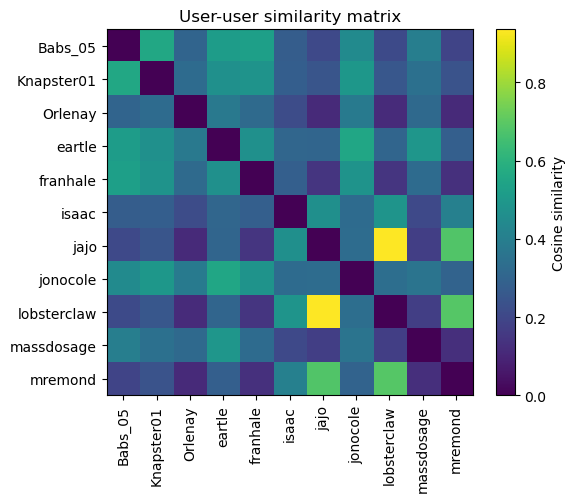

In [37]:
user_sim = cosine_similarity(train_mat)
np.fill_diagonal(user_sim, 0)

ucf_scores = user_sim.dot(train_mat.toarray())
print("User-based CF score matrix shape:", ucf_scores.shape)

plt.figure(figsize=(6, 5))
plt.imshow(user_sim, cmap='viridis')
plt.colorbar(label='Cosine similarity')
plt.xticks(range(n_users), users, rotation=90)
plt.yticks(range(n_users), users)
plt.title('User-user similarity matrix')
plt.tight_layout()
plt.show()

## Algorithm 2 — Matrix Factorization (Implicit ALS)
For our second algorithm, we use the Alternating Least Squares (ALS) implementation from the implicit library. This method was specifically designed for implicit feedback data like play counts. Instead of treating each play as a rating, ALS treats play counts as confidence levels. A song played 20 times gives us more confidence that the user likes that artist than a song played once. This approach comes from a well known 2008 paper by Hu, Koren, and Volinsky (Hu, Koren & Volinsky, 2008). The algorithm learns hidden factors for each user and each artist, then uses those factors to predict which artists a user is most likely to play next.

In [38]:
als_model = implicit.als.AlternatingLeastSquares(
    factors=20, regularization=0.1, iterations=20, random_state=42
)
als_model.fit(train_mat * 10)  # confidence scaling

als_scores = als_model.user_factors.dot(als_model.item_factors.T)
print("ALS score matrix shape:", als_scores.shape)

  0%|          | 0/20 [00:00<?, ?it/s]

ALS score matrix shape: (11, 22823)


### Accuracy Evaluation — Precision@k, Recall@k, NDCG@k
Since we're working with implicit feedback (plays, not star ratings), we can't use metrics like RMSE or MAE. There's no "wrong rating" to measure. All we care about is whether we recommended artists the user actually went on to play.So we use ranking accuracy metrics instead, evaluated on the held-out test data:

- Precision@k: Of the k artists we recommended, how many did the user actually listen to in the test set?
- Recall@k: Of all the artists the user listened to in the test set, how many did we include in our top k recommendations?
- (Normalized Discounted Cumulative Gain) NDCG@k: Similar to precision, but it gives extra credit when highly relevant artists appear higher up in the recommendation list.

In [39]:
def topk_recs(scores, u, k, exclude):
    s = scores[u].copy()
    s[list(exclude)] = -np.inf
    return np.argsort(-s)[:k]

def precision_recall_ndcg_at_k(scores, k=10):
    precisions, recalls, ndcgs = [], [], []
    for u in range(n_users):
        if u not in test_dict:
            continue
        truth = test_dict[u]
        exclude = train_dict.get(u, set())
        recs = topk_recs(scores, u, k, exclude)
        hits = [1 if r in truth else 0 for r in recs]
        n_hit = sum(hits)
        precisions.append(n_hit / k)
        recalls.append(n_hit / len(truth))
        dcg = sum(h / np.log2(idx + 2) for idx, h in enumerate(hits))
        idcg = sum(1 / np.log2(idx + 2) for idx in range(min(len(truth), k)))
        ndcgs.append(dcg / idcg if idcg > 0 else 0)
    return np.mean(precisions), np.mean(recalls), np.mean(ndcgs)

results = {}
for name, scores in [('User-based CF', ucf_scores), ('ALS Matrix Factorization', als_scores)]:
    p, r, n = precision_recall_ndcg_at_k(scores, k=10)
    results[name] = {'Precision@10': p, 'Recall@10': r, 'NDCG@10': n}

acc_df = pd.DataFrame(results).T
acc_df

,Precision@10,Recall@10,NDCG@10
User-based CF,0.709091,0.013630,0.724577
ALS Matrix Factorization,0.845455,0.034287,0.883982


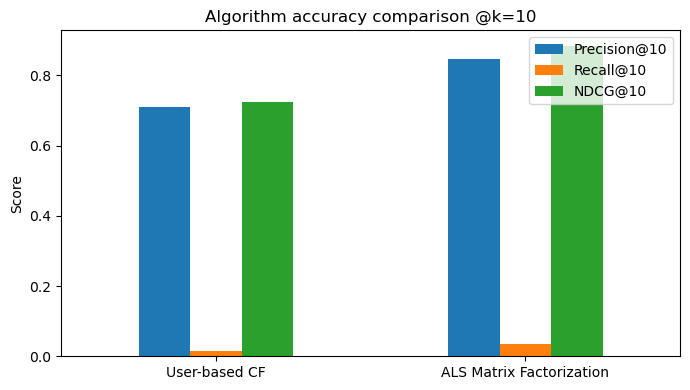

In [40]:
acc_df.plot(kind='bar', figsize=(7, 4), rot=0)
plt.title('Algorithm accuracy comparison @k=10')
plt.ylabel('Score')
plt.legend(loc='upper right')
plt.tight_layout()
plt.show()

Matrix factorization beats user-based CF on every accuracy metric. With only 11 users, user-based CF can only compare each user to 10 others. That's a very small pool, so the system struggles to find truly similar users. As a result, the recommendations are rough and not very personalized. It's like asking only 10 people for music suggestions instead of thousands, you get broad guesses instead of spot-on matches. ALS, on the other hand, learns 20 latent factors from the entire interaction matrix across all 22,800 artists. This gives it much more information to score artists a user hasn't played yet. Recall@10 looks low for both models, in the single digits. But that's expected. Each user has hundreds of held-out test artists, and we're only recommending 10. So recall is naturally capped at a low number no matter how good the model is. Precision and NDCG are the more useful metrics to compare here. We'll use ALS as the base model for the diversity and novelty work going forward, since it's the stronger of the two.

### Beyond accuracy: Adding diversity and novelty with MMR re-ranking
Business goal: A user who keeps seeing the same artists over and over, even if those recommendations are accurate, has a worse experience than someone who gets exposed to variety. So we implement a technique called Maximal Marginal Relevance (MMR). Instead of just picking the top k highest scoring artists, we build the recommendation list step by step. At each step, we balance two things: how relevant the artist is (how likely the user is to like them) and how different they are from artists already in the list. This way, the final list doesn't cluster around one small corner of the artist space.

Since this dataset has no genre information, we use the ALS item factors as a way to measure how similar two artists are. These factors are the hidden features the model learned, and they work as a stand-in for artist "embeddings."

Here's the formula:
$$MMR = \arg\max_{i \in R \setminus S} \Big[ \lambda \cdot \text{rel}(i) - (1-\lambda) \cdot \max_{j \in S} \text{sim}(i,j) \Big]$$

MMR picks the artist that maximizes relevance minus similarity to already chosen artists. The lambda parameter controls the trade-off. A high lambda means we care more about relevance, and a low lambda means we care more about diversity.

We also track two beyond accuracy metrics:

- Intra-list diversity (ILD): Measures how different the artists in the recommendation list are from each other. Higher is better. (1 − cosine similarity in embedding space)
- Novelty: Measures how obscure or surprising the recommendations are. average $-\log_2(\text{popularity})$ . Less popular artists score higher.






In [41]:
item_factors = als_model.item_factors
norms = np.linalg.norm(item_factors, axis=1, keepdims=True)
norms[norms == 0] = 1
item_factors_n = item_factors / norms

item_pop = np.asarray(train_mat.sum(axis=0)).flatten()
item_pop_norm = item_pop / item_pop.sum()
eps = 1e-12
novelty_score = -np.log2(item_pop_norm + eps)

def mmr_rerank(scores_u, exclude, k=10, lam=0.5, pool_size=50):
    s = scores_u.copy()
    s[list(exclude)] = -np.inf
    cand_set = list(np.argsort(-s)[:pool_size])
    pool_scores = s[cand_set]
    rel_min, rel_max = pool_scores.min(), pool_scores.max()
    rel_norm = (pool_scores - rel_min) / (rel_max - rel_min + eps)
    rel_map = dict(zip(cand_set, rel_norm))

    selected = []
    while len(selected) < k and cand_set:
        best_item, best_val = None, -np.inf
        for c in cand_set:
            rel = rel_map[c]
            max_sim = item_factors_n[c].dot(item_factors_n[selected].T).max() if selected else 0
            mmr_val = lam * rel - (1 - lam) * max_sim
            if mmr_val > best_val:
                best_val, best_item = mmr_val, c
        selected.append(best_item)
        cand_set.remove(best_item)
    return np.array(selected)

In [43]:
def eval_recs(rec_func, k=10):
    precisions, recalls, ndcgs, ilds, novelties = [], [], [], [], []
    for u in range(n_users):
        if u not in test_dict:
            continue
        truth = test_dict[u]
        exclude = train_dict.get(u, set())
        recs = rec_func(u, exclude, k)
        hits = [1 if r in truth else 0 for r in recs]
        n_hit = sum(hits)
        precisions.append(n_hit / k)
        recalls.append(n_hit / len(truth))
        dcg = sum(h / np.log2(idx + 2) for idx, h in enumerate(hits))
        idcg = sum(1 / np.log2(idx + 2) for idx in range(min(len(truth), k)))
        ndcgs.append(dcg / idcg if idcg > 0 else 0)
        if len(recs) > 1:
            sim_matrix = item_factors_n[recs].dot(item_factors_n[recs].T)
            iu = np.triu_indices(len(recs), k=1)
            ilds.append(1 - sim_matrix[iu].mean())
        novelties.append(novelty_score[recs].mean())
    return {
        'Precision@10': np.mean(precisions), 'Recall@10': np.mean(recalls),
        'NDCG@10': np.mean(ndcgs), 'ILD': np.mean(ilds), 'Novelty': np.mean(novelties)
    }

def als_rec(u, exclude, k):
    s = als_scores[u].copy()
    s[list(exclude)] = -np.inf
    return np.argsort(-s)[:k]

def mmr_rec_factory(lam):
    def f(u, exclude, k):
        return mmr_rerank(als_scores[u], exclude, k=k, lam=lam, pool_size=50)
    return f

comparison = {'ALS (baseline, no re-ranking)': eval_recs(als_rec, k=10)}
for lam in [0.7, 0.5, 0.3]:
    comparison[f'ALS + MMR (lambda={lam})'] = eval_recs(mmr_rec_factory(lam), k=10)

comparison_df = pd.DataFrame(comparison).T
comparison_df

,Precision@10,Recall@10,NDCG@10,ILD,Novelty
"ALS (baseline, no re-ranking)",0.845455,0.034287,0.883982,0.528121,9.634722
ALS + MMR (lambda=0.7),0.854545,0.034699,0.885919,0.593715,9.640250
ALS + MMR (lambda=0.5),0.763636,0.027809,0.796072,0.724606,9.601112
ALS + MMR (lambda=0.3),0.709091,0.020890,0.727950,0.806101,10.000467


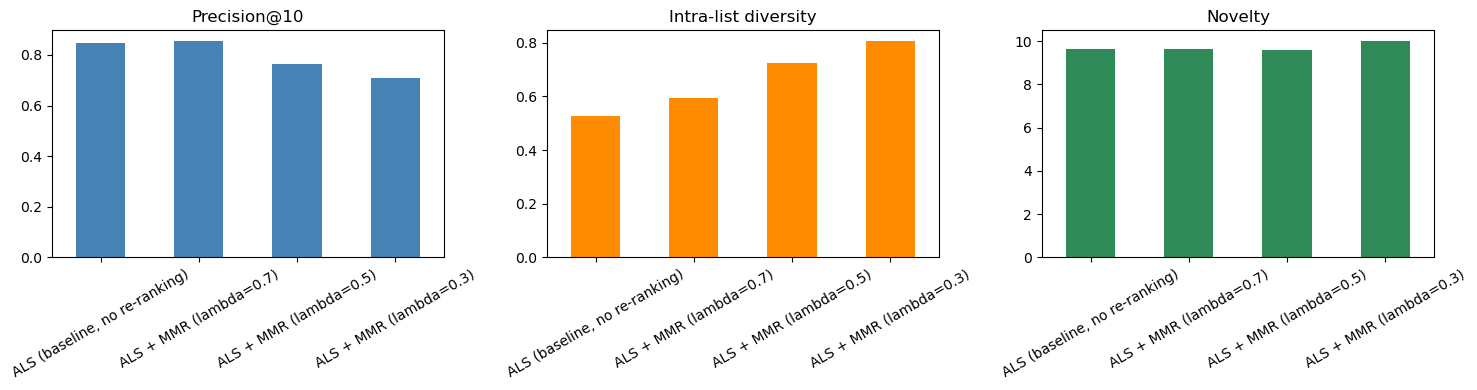

In [44]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
comparison_df['Precision@10'].plot(kind='bar', ax=axes[0], color='steelblue', rot=30)
axes[0].set_title('Precision@10')
comparison_df['ILD'].plot(kind='bar', ax=axes[1], color='darkorange', rot=30)
axes[1].set_title('Intra-list diversity')
comparison_df['Novelty'].plot(kind='bar', ax=axes[2], color='seagreen', rot=30)
axes[2].set_title('Novelty')
plt.tight_layout()
plt.show()

### Accuracy and Diversity Trade-off
MMR re-ranking creates a clear trade-off between accuracy and diversity:

Diversity increases steadily as lambda decreases from 0.7 to 0.3 (0.53 to 0.81).
Accuracy drops gradually, not sharply, losing about 12 to 14 points at the most diverse setting.
Novelty barely changes, showing that diversity and novelty are different.
Lambda equals 0.7 seems like the sweet spot: good diversity gain for a small accuracy loss. Lambda equals 0.3 costs too much accuracy. But offline metrics might not fully capture user value for discovery.

### Discussion 

ALS beat user-based CF on all accuracy metrics. This makes sense because there are only 11 users. User-based CF needs similar users to learn from, but with only 10 neighbors per user, it doesn't have enough data. ALS does not rely on similar users. It learns patterns from the whole artist matrix, so it performs better.

MMR gave us a useful trade-off. We increased diversity without losing much accuracy. Novelty stayed about the same, so diversity and novelty are not the same thing.

Offline metrics are limited. They only show what users listened to, not what they liked. They also have bias because past recommendations shaped what users heard. To really know if diversity helps, we need to test with real users. Only then can we measure true discovery, long-term engagement, and direct feedback.

An A/B test would work. One group would get plain ALS recommendations. The other group would get ALS plus MMR with lambda equals 0.7, which gave the best balance in our offline tests. We would track clicks, how much users played, and whether they came back to the artist later. We would also watch session length and skip rates to make sure diversity did not hurt the experience. The test would need to run for a few weeks to capture weekly listening habits.

We should also split results by user type. Users who listen to many genres might value diversity more than users who stick to one or two genres. The average effect might not apply to everyone.